In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import datetime



In [163]:
df = pd.read_csv('sales_revenue.csv')


df.head(5)


,Order_ID,Order_Date,Region,Sales_Rep,Product_Category,Product_Name,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Deal_Status,Channel
0,ORD-10890,02/13/2024,East,Aisha Patel,Hardware,ServerX,Startup,2,1544.63,0.11,2749.44,LOST,referral
1,ORD-10094,2024-10-05,NaN,Aisha Patel,Subscriptions,Pro Plan,NaN,43,4749.43,0.24,155211.37,LOST,Online
2,ORD-10107,2024-01-23,south,Mia Fernandez,Hardware,ServerX,smb,12,1402.69,0.27,12287.56,Won,Partner
3,ORD-10609,08/07/2022,north,Mia Fernandez,Services,Onboarding,start-up,14,1769.22,0.03,24026.01,Pending,Direct
4,ORD-10113,16-08-2023,north,James Carter,Consulting,Strategy Session,ENTERPRISE,35,3533.17,0.18,101401.98,Pending,partner


In [4]:
df.shape

(1000, 13)

In [5]:
df.columns.values

array(['Order_ID', 'Order_Date', 'Region', 'Sales_Rep',
       'Product_Category', 'Product_Name', 'Customer_Segment', 'Quantity',
       'Unit_Price', 'Discount_Rate', 'Revenue', 'Deal_Status', 'Channel'],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   object 
 1   Order_Date        1000 non-null   object 
 2   Region            948 non-null    object 
 3   Sales_Rep         948 non-null    object 
 4   Product_Category  1000 non-null   object 
 5   Product_Name      1000 non-null   object 
 6   Customer_Segment  937 non-null    object 
 7   Quantity          1000 non-null   int64  
 8   Unit_Price        1000 non-null   float64
 9   Discount_Rate     923 non-null    float64
 10  Revenue           961 non-null    float64
 11  Deal_Status       931 non-null    object 
 12  Channel           961 non-null    object 
dtypes: float64(3), int64(1), object(9)
memory usage: 101.7+ KB


In [7]:
df.dtypes

Order_ID             object
Order_Date           object
Region               object
Sales_Rep            object
Product_Category     object
Product_Name         object
Customer_Segment     object
Quantity              int64
Unit_Price          float64
Discount_Rate       float64
Revenue             float64
Deal_Status          object
Channel              object
dtype: object

In [8]:
df.describe()

,Quantity,Unit_Price,Discount_Rate,Revenue
count,1000.000000,1000.000000,923.000000,9.610000e+02
mean,56.254000,2953.851260,0.176566,9.214820e+04
std,546.277311,8761.317278,0.097991,6.425284e+05
min,-5.000000,-50.000000,0.000000,-1.000000e+03
25%,13.000000,1137.595000,0.100000,1.346262e+04
50%,25.000000,2353.555000,0.170000,3.764886e+04
75%,38.000000,3649.587500,0.260000,7.557927e+04
max,9999.000000,150000.000000,0.350000,9.999999e+06


In [ ]:

df_clean = df.copy()

In [274]:
df_clean.duplicated().sum() # check for duplicates

np.int64(40)

In [ ]:

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

In [276]:
df_clean.duplicated().sum()


np.int64(0)

In [ ]:
# standardize ENTERPRISE/enterprise/Enterprise to Enterprise

df_clean['Customer_Segment'] = df_clean['Customer_Segment'].str.strip().str.title()


In [278]:
df_clean['Customer_Segment'] = df_clean['Customer_Segment'].str.replace('Smb', 'SMB', case=True, regex=False)

In [279]:
df_clean['Customer_Segment'] = df_clean['Customer_Segment'].replace({'Start-Up': 'Startup'})

In [280]:
df_clean['Customer_Segment'].value_counts()

Customer_Segment
Startup       338
Enterprise    334
SMB           231
Name: count, dtype: int64

In [282]:
df_clean['Region'] = df_clean['Region'].str.strip().str.title()

In [283]:
df_clean['Product_Category'] = df_clean['Product_Category'].str.strip().str.title()

In [284]:
df_clean['Region'].value_counts()

Region
North      246
Central    172
West       170
South      166
East       158
Name: count, dtype: int64

In [286]:
df_clean['Deal_Status'] = df_clean['Deal_Status'].str.strip().str.title()
df_clean['Channel'] = df_clean['Channel'].str.strip().str.title()

In [287]:
df_clean['Deal_Status'].value_counts()

Deal_Status
Pending        279
Lost           266
Won            252
In Progress     96
Name: count, dtype: int64

In [288]:
df_clean['Channel'] = df_clean['Channel'].str.strip().str.title()

In [233]:
df_clean['Channel'].value_counts()

Channel
Online      287
Direct      277
Partner     179
Referral    171
Name: count, dtype: int64

In [ ]:

df_clean['Deal_Status'] = df_clean['Deal_Status'].replace({'In Progress': 'Pending'})
df_clean['Deal_Status'].value_counts()

Deal_Status
Pending    375
Lost       266
Won        252
Name: count, dtype: int64

In [290]:
df_clean['Sales_Rep'].value_counts()

Sales_Rep
Nina Torres      107
Liam Brooks       99
Marcus Webb       95
James Carter      93
Zoe Nguyen        89
Sophia Lee        89
Mia Fernandez     87
Derek Stone       86
Ethan Ross        85
Aisha Patel       82
Name: count, dtype: int64

In [292]:
df_clean['Order_Date'].value_counts().head(20)

Order_Date
11/09/2023           5
30-01-2023           3
08/03/2022           3
October 01, 2022     3
01/01/2022           3
10/21/2024           3
16/09/2022           3
12/07/2023           3
14/02/2023           2
December 30, 2022    2
21/05/2023           2
March 19, 2022       2
16-04-2022           2
2024-04-16           2
29-09-2023           2
12-06-2024           2
19-08-2023           2
October 05, 2022     2
16/07/2022           2
06/03/2022           2
Name: count, dtype: int64

In [293]:
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], format='mixed', dayfirst=True, errors='coerce')

In [294]:
print(df_clean['Order_Date'].isna().sum())

0


In [295]:
print(df_clean.shape)

(960, 13)


In [296]:
Q1 = df_clean['Quantity'].quantile(0.25)
Q3 = df_clean['Quantity'].quantile(0.75)
IQR = Q3 - Q1


In [297]:
print(Q1)
print(Q3)
print(IQR)

13.0
38.0
25.0


In [298]:
# now lets calculate the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [299]:
print(lower_bound)
print(upper_bound)

-24.5
75.5


In [300]:
df_clean = df_clean[(df_clean['Quantity'] >= 0) & (df_clean['Quantity'] <= upper_bound)]

In [301]:
df_clean.shape

(953, 13)

In [302]:
Q1_Unit = df_clean['Unit_Price'].quantile(0.25)
Q3_Unit = df_clean['Unit_Price'].quantile(0.75)
IQR_Unit = Q3_Unit - Q1_Unit

In [303]:
print(Q1_Unit)
print(Q3_Unit)
print(IQR_Unit)

1137.82
3657.71
2519.8900000000003


In [304]:
lower_bound_unit = Q1_Unit - 1.5 * IQR_Unit
upper_bound_unit = Q3_Unit + 1.5 * IQR_Unit

In [305]:
print(lower_bound_unit) 
print(upper_bound_unit)


-2642.0150000000003
7437.545


In [185]:
df_clean_unit = df_clean[(df_clean['Unit_Price'] >= 0) & (df_clean['Unit_Price'] <= upper_bound_unit)]

In [306]:
df_clean_unit.shape

(945, 13)

In [307]:
Q1_Revenue = df_clean['Revenue'].quantile(0.25)
Q3_Revenue = df_clean['Revenue'].quantile(0.75)
IQR_Revenue = Q3_Revenue - Q1_Revenue

In [308]:
print(Q1_Revenue)
print(Q3_Revenue)
print(IQR_Revenue)

13406.71
76482.1
63075.39000000001


In [309]:
lower_bound_Revenue = Q1_Revenue - 1.5 * IQR_Revenue
upper_bound_Revenue = Q3_Revenue + 1.5 * IQR_Revenue

In [194]:
print(lower_bound_Revenue)
print(upper_bound_Revenue)

-80216.82499999998
169445.935


In [310]:
df_clean = df_clean[(df_clean['Revenue'] >= 0) & (df_clean['Revenue'] <= upper_bound_Revenue)]

In [311]:
df_clean.shape

(884, 13)

In [312]:
df_clean.isnull().sum()

Order_ID             0
Order_Date           0
Region              41
Sales_Rep           46
Product_Category     0
Product_Name         0
Customer_Segment    53
Quantity             0
Unit_Price           0
Discount_Rate       70
Revenue              0
Deal_Status         64
Channel             34
dtype: int64

In [ ]:

df_clean['Region'] = df_clean['Region'].fillna(df_clean['Region'].mode()[0]) # fill missing values in Region column with the mode (most frequent value)
df_clean['Region'].isnull().sum() # check if there are still any missing values

np.int64(0)

In [314]:
df_clean['Region'].isnull().sum() # check if there are still any missing values

np.int64(0)

In [316]:
df_clean['Sales_Rep'] = df_clean['Sales_Rep'].fillna(df_clean['Sales_Rep'].mode()[0]) # fill missing values in Sales_Rep column with the mode (most frequent value)
df_clean['Sales_Rep'].isnull().sum() # check if there are still any missing values

np.int64(0)

In [317]:
df_clean['Customer_Segment'] = df_clean['Customer_Segment'].fillna(df_clean['Customer_Segment'].mode()[0]) # fill missing values in Customer_Segment column with the mode (most frequent value) 
df_clean['Customer_Segment'].isnull().sum()

np.int64(0)

In [210]:
df_clean['Deal_Status'] = df_clean['Deal_Status'].fillna(df_clean['Deal_Status'].mode()[0]) # fill missing values in Deal_Status column with the mode (most frequent value)
df_clean['Deal_Status'].isnull().sum() # check if there are still any missing values

np.int64(0)

In [318]:
df_clean['Channel'] = df_clean['Channel'].fillna(df_clean['Channel'].mode()[0])
df_clean['Channel'].isnull().sum()

np.int64(0)

In [319]:
# LETS FILLIN MEAN WITH THE DISCOUNT_RATE 
df_clean['Discount_Rate'] = df_clean['Discount_Rate'].fillna(df_clean['Discount_Rate'].mean()) # fill missing values in Discount_Rate column with the mean
df_clean['Discount_Rate'].isnull().sum() # check if there are still any missing values

np.int64(0)

In [ ]:

df_clean['Revenue'] = df_clean['Revenue'].fillna(df_clean['Revenue'].mean()) # fill missing values in Revenue column with the mean
df_clean['Revenue'].isnull().sum() # check if there are still any missing values

np.int64(0)

In [321]:
df_clean.isnull().sum()

Order_ID             0
Order_Date           0
Region               0
Sales_Rep            0
Product_Category     0
Product_Name         0
Customer_Segment     0
Quantity             0
Unit_Price           0
Discount_Rate        0
Revenue              0
Deal_Status         64
Channel              0
dtype: int64

In [322]:
df_clean.shape


(884, 13)

In [323]:
df_clean.dtypes

Order_ID                    object
Order_Date          datetime64[ns]
Region                      object
Sales_Rep                   object
Product_Category            object
Product_Name                object
Customer_Segment            object
Quantity                     int64
Unit_Price                 float64
Discount_Rate              float64
Revenue                    float64
Deal_Status                 object
Channel                     object
dtype: object

In [324]:
df_clean['Revenue'].describe()

count       884.000000
mean      47044.468903
std       40250.766811
min           0.000000
25%       12915.220000
50%       35587.900000
75%       71051.475000
max      168068.940000
Name: Revenue, dtype: float64

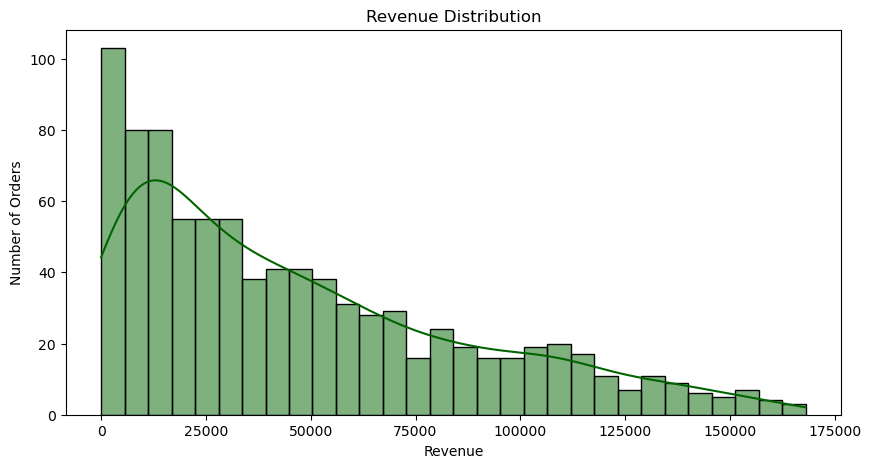

In [325]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Revenue'], bins=30, kde=True, color='darkgreen')
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Number of Orders')
plt.show()

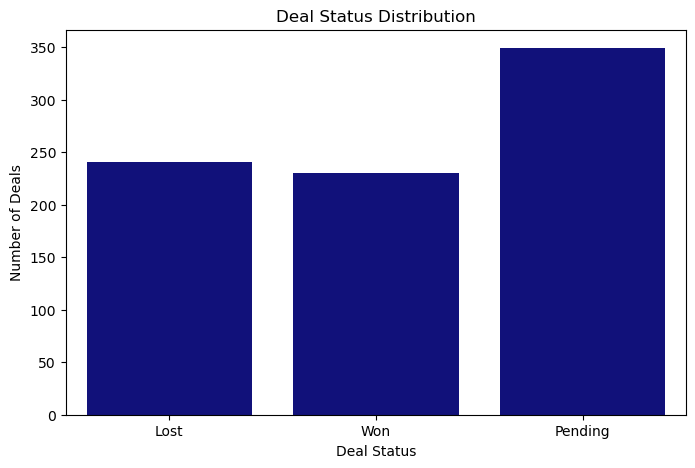

In [326]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Deal_Status', color='darkblue')
plt.title('Deal Status Distribution')
plt.xlabel('Deal Status')
plt.ylabel('Number of Deals')
plt.show()

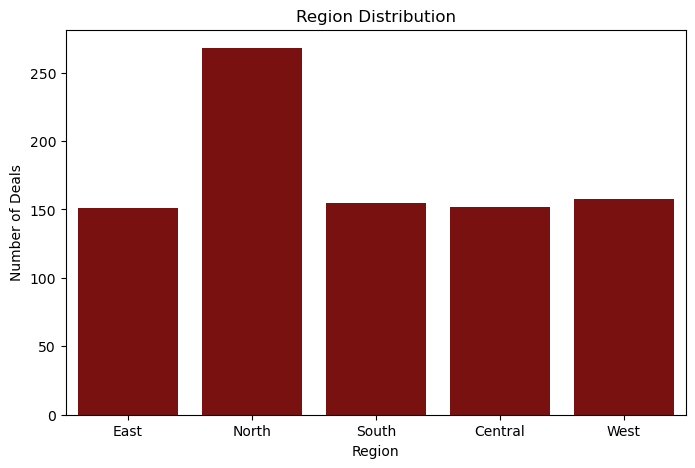

In [327]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Region', color='darkred')
plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Number of Deals')
plt.show()



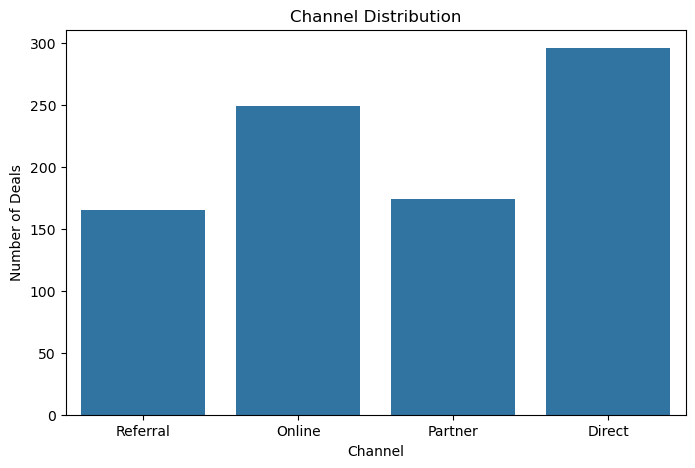

In [331]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Channel')
plt.title('Channel Distribution')
plt.xlabel('Channel')
plt.ylabel('Number of Deals')
plt.show()

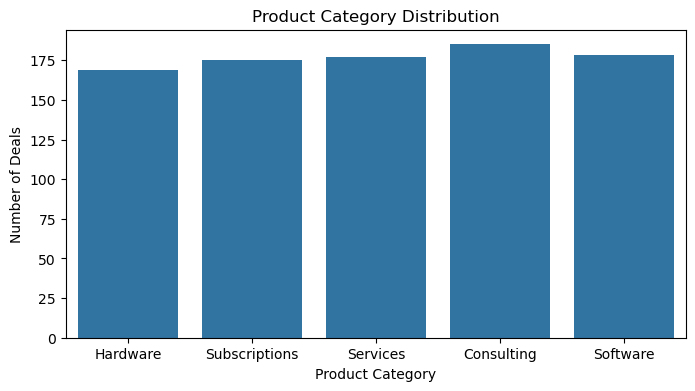

In [348]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='Product_Category')
plt.title('Product Category Distribution')
plt.xlabel('Product Category')
plt.ylabel('Number of Deals')
plt.show()

In [337]:
df_clean.groupby('Region')['Revenue'].mean().sort_index(ascending=True)

Region
Central    41738.464013
East       44215.188940
North      49539.691418
South      50446.519161
West       47283.054937
Name: Revenue, dtype: float64

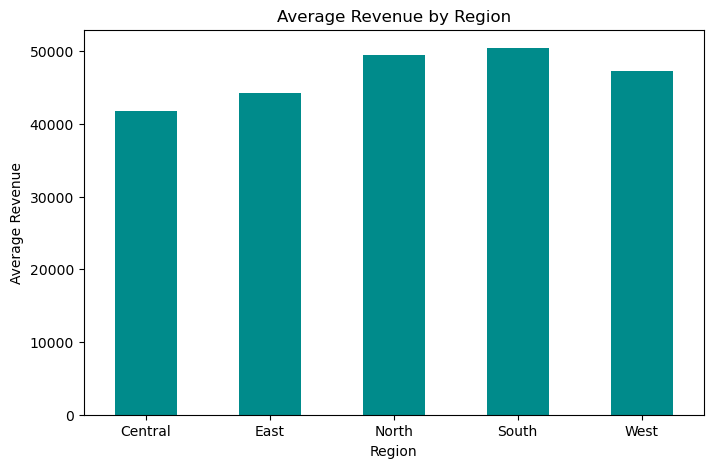

In [339]:
plt.figure(figsize=(8, 5))
df_clean.groupby('Region')['Revenue'].mean().plot(kind='bar', color='darkcyan')
plt.title('Average Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Average Revenue')
plt.xticks(rotation=0)
plt.show()

In [341]:
df_clean.groupby('Product_Category')['Revenue'].mean()

Product_Category
Consulting       50304.280216
Hardware         44729.284497
Services         43402.053277
Software         44549.954888
Subscriptions    52055.509657
Name: Revenue, dtype: float64

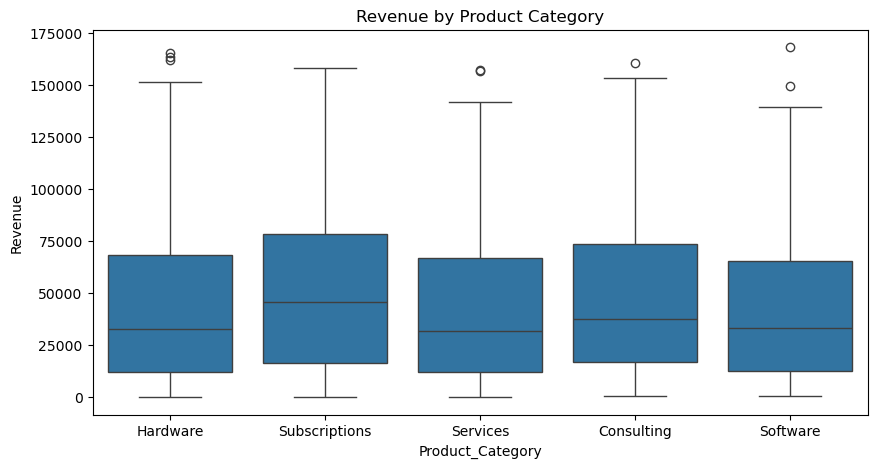

In [343]:
plt.figure(figsize=(10, 5)) 
sns.boxplot(data=df_clean, x='Product_Category', y='Revenue')
plt.title('Revenue by Product Category')
plt.show()

In [355]:
df_clean.groupby('Sales_Rep')['Revenue'].mean().sort_values(ascending=False)
# sort to see the top sales rep


Sales_Rep
Aisha Patel      58419.610676
Ethan Ross       54406.400513
Marcus Webb      51216.461333
James Carter     49877.352500
Nina Torres      47159.906986
Liam Brooks      46328.595506
Zoe Nguyen       44025.178902
Derek Stone      42510.124359
Sophia Lee       39929.722195
Mia Fernandez    37193.801728
Name: Revenue, dtype: float64

<Axes: ylabel='Sales_Rep'>

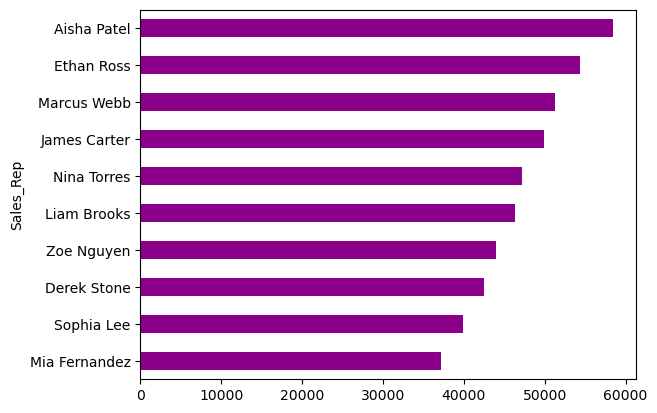

In [358]:
df_clean.groupby('Sales_Rep')['Revenue'].mean().sort_values(ascending=True).plot(kind='barh', color='darkmagenta')


In [359]:
df_clean.groupby('Channel')['Revenue'].mean().sort_values(ascending=False)

Channel
Direct      50105.034966
Partner     46739.213621
Online      45376.188112
Referral    44393.491818
Name: Revenue, dtype: float64

<Axes: ylabel='Channel'>

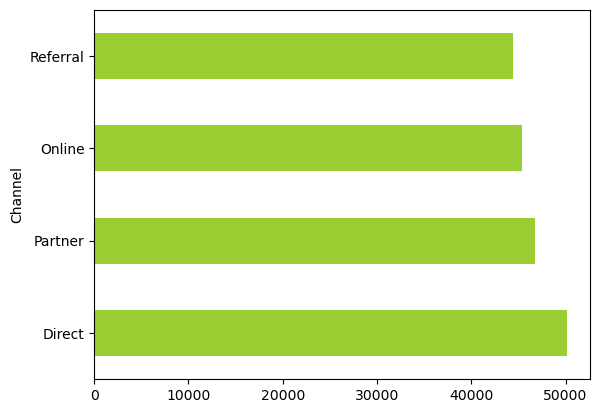

In [362]:
df_clean.groupby('Channel')['Revenue'].mean().sort_values(ascending=False).plot(kind='barh', color='Yellowgreen')

<Axes: xlabel='Region'>

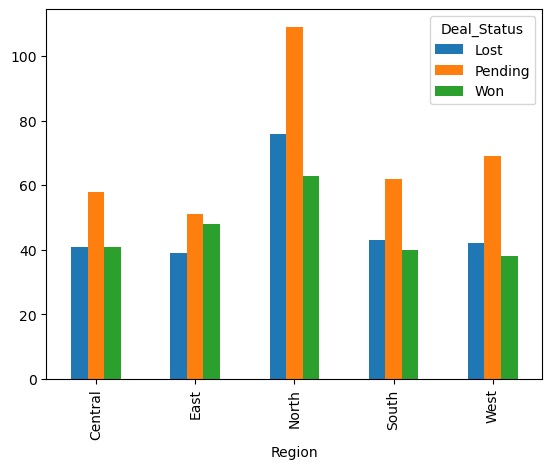

In [382]:

pd.crosstab(df_clean['Region'], df_clean['Deal_Status']).plot(kind = 'bar')

In [368]:
corr_matrix = df_clean.corr(numeric_only=True)
corr_matrix

,Quantity,Unit_Price,Discount_Rate,Revenue
Quantity,1.000000,0.003567,0.019709,0.599629
Unit_Price,0.003567,1.000000,0.014054,0.128775
Discount_Rate,0.019709,0.014054,1.000000,-0.076550
Revenue,0.599629,0.128775,-0.076550,1.000000


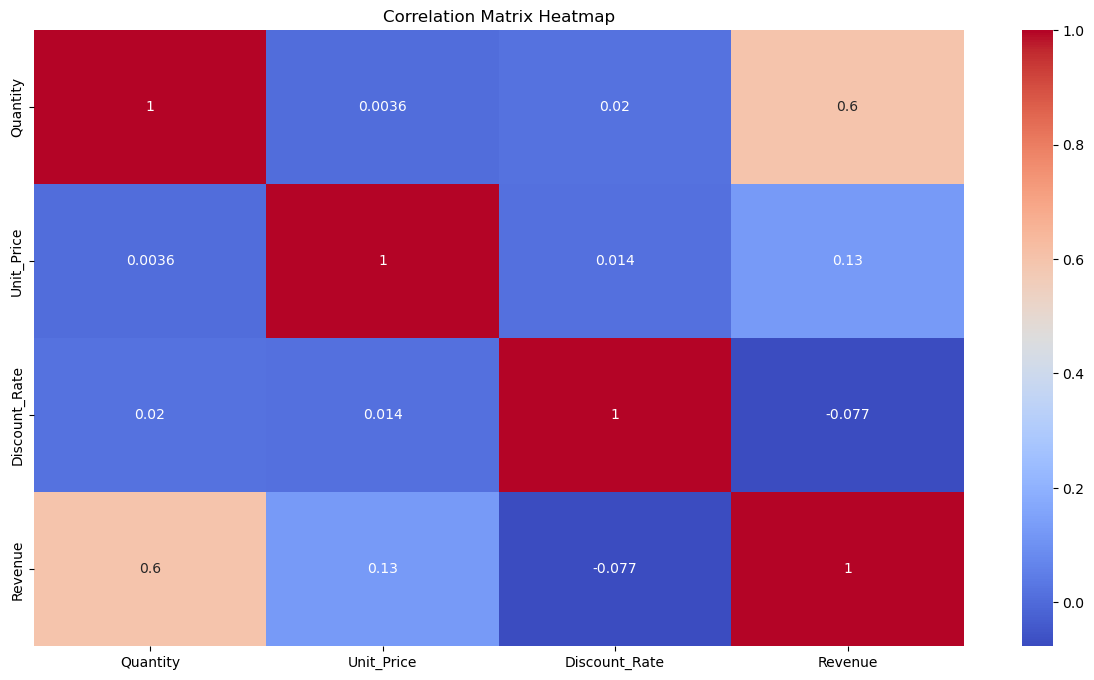

In [ ]:

plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

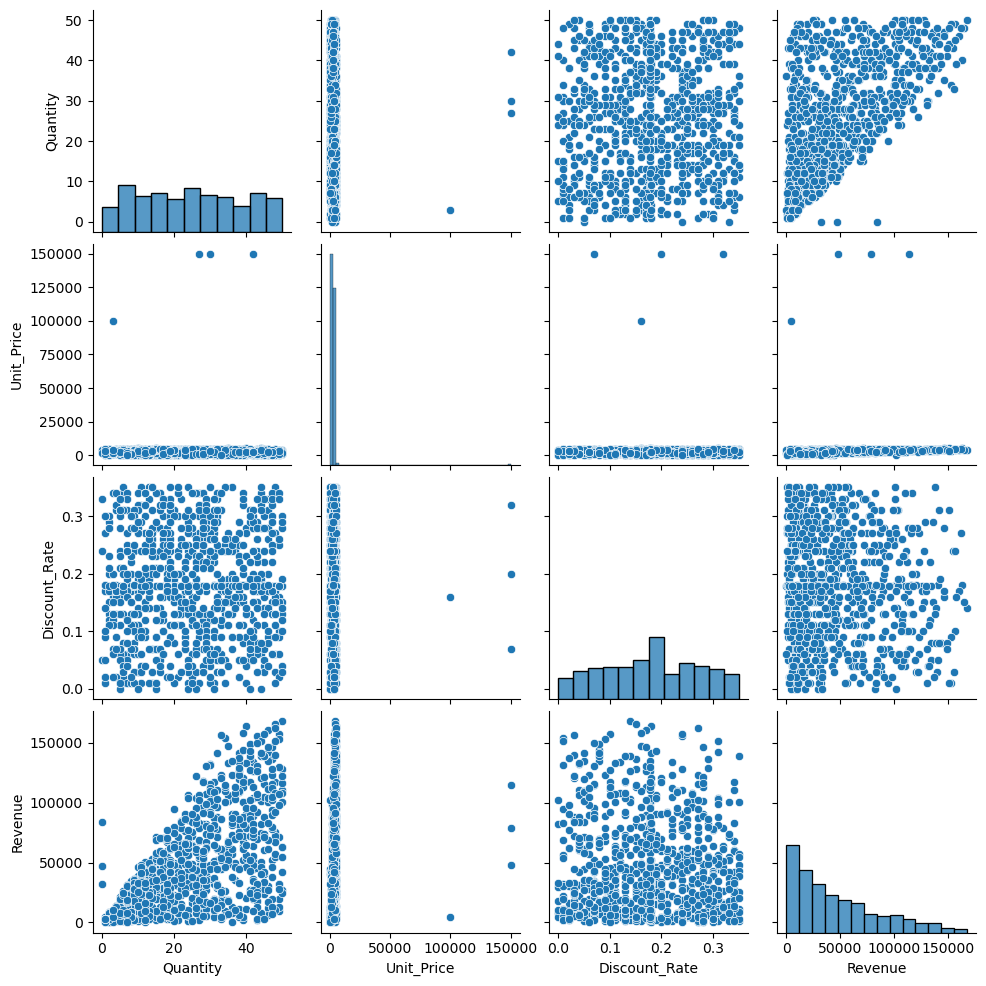

In [384]:
sns.pairplot(df_clean)